In [3]:
import requests
import random
import os
import json
import csv
import logging
import numpy as np
import pandas as pd
import torch
import gensim.downloader as api
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from pykeen.triples import TriplesFactory
from pykeen.models import TransE, DistMult
from pykeen.training import SLCWATrainingLoop

logging.basicConfig(level=logging.INFO)

/Users/giacomomunda/Documents/MSc Multilingual Technologies/Masters_Thesis/code/kg_linear_transformation/linear-venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# DBPedia

In [5]:

endpoint = "http://dbpedia.org/sparql"
query = """
SELECT DISTINCT ?relatedEntity ?label
WHERE {
  dbr:Germany ?predicate ?relatedEntity.
  ?relatedEntity rdfs:label ?label.
  FILTER(LANG(?label) = 'en')
}
"""

params = {'format': 'json', 'query': query}
response = requests.get(endpoint, params=params)
data = response.json()

entities = [(result['relatedEntity']['value'], result['label']['value']) for result in data['results']['bindings']]

for uri, label in entities[:3]:
    print(f"Entity: {uri}, Label: {label}")

Entity: http://dbpedia.org/ontology/Person, Label: person
Entity: http://dbpedia.org/ontology/Place, Label: place
Entity: http://dbpedia.org/resource/Cabinet_of_Germany, Label: Cabinet of Germany


# Wikidata

In [2]:
# Decreasing the size of the Wikidata5M dataset

file = '../data/wikidata5m_inductive/wikidata5m_inductive_train.txt'
output_file = '../data/wikidata5m_inductive/wikidata5m_inductive_train_30k.tsv'
num_samples = 30_000

with open(file, 'r') as f:
    lines = f.readlines()

random_sample = random.sample(lines, num_samples)

with open(output_file, 'w') as f:
    f.writelines(random_sample)

In [8]:
ds = pd.read_csv(output_file, sep='\t', header=None)
ds.columns = ['head', 'relation', 'tail']
num_relations = ds['relation'].unique()
print(f"Number of relations: {len(num_relations)}")

relations_counts = ds['relation'].value_counts()
print(f"Value counts of relation: {relations_counts}")


Number of relations: 340
Value counts of relation: relation
P31      5593
P17      1975
P27      1668
P106     1563
P54      1326
         ... 
P1533       1
P1875       1
P562        1
P1302       1
P669        1
Name: count, Length: 340, dtype: int64


In [2]:
# Creating a JSONL file from the Wikidata5M dataset
# with the text values of the entities instead of their IDs

def get_entity_info(wikidata_id):
    try:
        wikidata_api_url = f"https://www.wikidata.org/w/api.php?action=wbgetentities&format=json&ids={wikidata_id}"
        response = requests.get(wikidata_api_url)
        response.raise_for_status()  # Raise an exception for 4xx or 5xx status codes
        data = response.json()
        return data['entities'][wikidata_id] if wikidata_id in data['entities'] else None
    except requests.RequestException as e:
        print(f"Error retrieving data for entity {wikidata_id}: {e}")
        return None
    except KeyError as e:
        print(f"Error processing data for entity {wikidata_id}: {e}")
        return None

def add_entity_values(entry):
    sub_info = get_entity_info(entry['sub_id'])
    pred_info = get_entity_info(entry['pred_id'])
    obj_info = get_entity_info(entry['obj_id'])

    entry['sub_value'] = sub_info['labels']['en']['value'] if sub_info and 'labels' in sub_info and 'en' in sub_info['labels'] else None
    entry['pred_value'] = pred_info['labels']['en']['value'] if pred_info and 'labels' in pred_info and 'en' in pred_info['labels'] else None
    entry['obj_value'] = obj_info['labels']['en']['value'] if obj_info and 'labels' in obj_info and 'en' in obj_info['labels'] else None

    return entry

def txt_to_jsonl(input_file, output_file):
    with open(input_file, 'r', encoding='utf-8') as txt_file:
        lines = txt_file.readlines()

    jsonl_entries = []
    for line in tqdm(lines):
        parts = line.strip().split('\t')
        # Extract subject, predicate, and object
        sub_id, pred_id, obj_id = parts
        entry = {
            'sub_id': sub_id,
            'pred_id': pred_id,
            'obj_id': obj_id
        }
        entry_with_values = add_entity_values(entry)
        jsonl_entries.append(entry_with_values)

    with open(output_file, 'w', encoding='utf-8') as jsonl_file:
        for entry in jsonl_entries:
            jsonl_file.write(json.dumps(entry, ensure_ascii=False) + '\n')

input_file = '../data/wikidata5m_inductive/wikidata5m_inductive_train_20k.tsv'
output_file = '../data/wikidata5m_inductive/wikidata5m_inductive_train_20k.jsonl'
txt_to_jsonl(input_file, output_file)

  0%|          | 14/20000 [00:21<8:25:42,  1.52s/it]


KeyboardInterrupt: 

In [5]:
# Making it faster

def fetch_entity_info(wikidata_ids):
    wikidata_api_url = "https://www.wikidata.org/w/api.php?action=wbgetentities&format=json&ids=" + "|".join(wikidata_ids)
    try:
        response = requests.get(wikidata_api_url)
        response.raise_for_status()
        data = response.json()
        return data['entities']
    except Exception as e:
        print(f"Error fetching entity information: {e}")
        return {}

def get_entity_info(wikidata_ids):
    entities_info = fetch_entity_info(wikidata_ids)
    return entities_info

def add_entity_values_batch(entries, batch_size=50):
    # Split entries into batches
    batches = [entries[i:i+batch_size] for i in range(0, len(entries), batch_size)]

    results = []
    with ThreadPoolExecutor(max_workers=5) as executor:
        for batch in tqdm(batches[:5], desc="Processing batches"):
            futures = []
            for entry in batch:
                wikidata_ids = [entry['sub_id'], entry['pred_id'], entry['obj_id']]
                futures.append(executor.submit(get_entity_info, wikidata_ids))
            for future in futures:
                result = future.result()
                results.append(result)

    return results

def txt_to_jsonl(input_file, output_file):
    with open(input_file, 'r', encoding='utf-8') as txt_file:
        lines = txt_file.readlines()

    jsonl_entries = []
    for line in lines:
        parts = line.strip().split('\t')
        # Extract subject, predicate, and object
        sub_id, pred_id, obj_id = parts
        entry = {
            'sub_id': sub_id,
            'pred_id': pred_id,
            'obj_id': obj_id
        }
        jsonl_entries.append(entry)

    # Batch processing of entries
    results = add_entity_values_batch(jsonl_entries)

    # Combine results and write to JSONL file
    with open(output_file, 'w', encoding='utf-8') as jsonl_file:
        for entry, entities_info in zip(jsonl_entries, results):
            sub_info = entities_info.get(entry['sub_id'], {})
            pred_info = entities_info.get(entry['pred_id'], {})
            obj_info = entities_info.get(entry['obj_id'], {})

            entry['sub_value'] = sub_info.get('labels', {}).get('en', {}).get('value')
            entry['pred_value'] = pred_info.get('labels', {}).get('en', {}).get('value')
            entry['obj_value'] = obj_info.get('labels', {}).get('en', {}).get('value')

            jsonl_file.write(json.dumps(entry, ensure_ascii=False) + '\n')


input_file = '../data/wikidata5m_inductive/wikidata5m_inductive_train_20k.tsv'
output_file = '../data/wikidata5m_inductive/wikidata5m_inductive_train_20k.jsonl'
txt_to_jsonl(input_file, output_file)

Processing batches:   0%|          | 0/5 [00:00<?, ?it/s]

Processing batches: 100%|██████████| 5/5 [00:36<00:00,  7.29s/it]


In [30]:
def get_entity_info(wikidata_id):
    wikidata_api_url = f"https://www.wikidata.org/w/api.php?action=wbgetentities&format=json&ids={wikidata_id}"
    response = requests.get(wikidata_api_url)
    data = response.json()
    return data['entities'][wikidata_id]

# Example usage
wikidata_id = "Q1778473"  # Replace with the Wikidata ID
entity_info = get_entity_info(wikidata_id)
entity_value = entity_info['labels']['en']['value']
entity_value

'Mêlée'

# TREx Dataset

In [24]:
input_file_path = "../data/data_lama/TREx/P108.jsonl"
output_file_path = "../data/dataset/TREx/TREx_relations_P108.jsonl"
predicate_description_file_path = "../data/data_lama/relations.jsonl"

predicate_dict = {}
with open(predicate_description_file_path, 'r') as predicate_file:
    for line in predicate_file:
        predicate_entry = json.loads(line)
        predicate_dict[predicate_entry['relation']] = predicate_entry['label']

def extract_metadata(entry):
    return{
        'sub_label': entry['sub_label'],
        'sub_uri': entry['sub_uri'],
        'obj_label': entry['obj_label'],
        'obj_uri': entry['obj_uri'],
        'predicate_label': predicate_dict.get(entry['predicate_id'], entry['predicate_id']),
        'predicate_id': entry['predicate_id'],
    }

with open(input_file_path, 'r') as input_file, open(output_file_path, 'w') as output_file:
    for line in input_file:
        entry = json.loads(line)
        metadata = extract_metadata(entry)
        output_file.write(json.dumps(metadata) + '\n')

print("Metadata extraction completed.")

Metadata extraction completed.


In [28]:
# Concatenate all TREx files into one

directory_path = "../data/dataset/TREx"
output_file_path = "../data/dataset/TREx_all.jsonl"

jsonl_files = [f for f in os.listdir(directory_path) if f.endswith(".jsonl")]

with open(output_file_path, 'w') as output_file:
    for jsonl_file in jsonl_files:
        file_path = os.path.join(directory_path, jsonl_file)

        with open(file_path, 'r') as input_file:
            for line in input_file:
                output_file.write(line)

print("Concatenation completed. Output file:", output_file_path)

Concatenation completed. Output file: ../data/dataset/TREx_all.jsonl


**Getting the name of an entity given its ID**

In [18]:
trial = requests.get("https://www.wikidata.org/wiki/Special:EntityData/Q7503555.json").json()
trial
# entity = requests.get('https://www.wikidata.org/w/api.php?action=wbgetentities&props=labels&ids=Q19675', format=json)

'Shreela Ghosh'

In [22]:
# get a value from a Wikidata ID
def get_value_from_wikidata_id(wikidata_id):
    wikidata_api_url = f"https://www.wikidata.org/wiki/Special:EntityData/{wikidata_id}.json"
    response = requests.get(wikidata_api_url)
    data = response.json()
    try:
        value = data['entities'][wikidata_id]['labels']['en']['value']
    except:
        value = None
    return value

# Example usage
subject_id = 'Q1358852'
predicate_id = 'P106'
object_id = 'Q33999'
subject = get_value_from_wikidata_id(wikidata_id)
predicate = get_value_from_wikidata_id(predicate_id)
object = get_value_from_wikidata_id(object_id)
print(subject)
print(predicate)
print(object)

Ernst Jaakson
occupation
actor


## Trasform the triples into a graph

In [1]:
import json
import networkx as nx
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import SAGEConv

/Users/giacomomunda/Documents/Data Science/Python Projects/Advanced/kg_linear_transformation/kg-linear/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
jsonl_file_path = "../data/dataset/TREx/TREx_relations_P17.jsonl"


def create_graph(file_path: str):
    graph = nx.DiGraph()

    with open(file_path, 'r') as jsonl_file:
        for line in jsonl_file:
            triple = json.loads(line)

            subject = triple['sub_label']
            object_ = triple['obj_label']
            predicate = triple['predicate_label']

            graph.add_node(subject)
            graph.add_node(object_)
            graph.add_edge(subject, object_, label=predicate)

    return graph


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import MessagePassing, global_add_pool, GraphConv

In [6]:
class GNNModel(MessagePassing):
    def __init__(self, in_channels, out_channels):
        super(GNNModel, self).__init__(aggr='add')
        self.conv1 = GraphConv(in_channels, out_channels)

    def forward(self, x, edge_index):
        return self.propagate(edge_index, x=x)
    
    def message(self,  x_i, x_j):
        return x_j
    
def graph_to_pyg_data(graph):
    edge_index = torch.tensor(list(graph.edges)).t().contiguous()
    x = torch.eye(graph.number_of_nodes()) # identity matrix
    data = Data(x=x, edge_index=edge_index)

    return data

model = GNNModel(in_channels=graph.number_of_nodes(), out_channels=graph.number_of_nodes())
data = graph_to_pyg_data(graph)
loader = DataLoader([data], batch_size=1, shuffle=False)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range (100):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out, torch.tensor([0]))
    loss.backward()
    optimizer.step()

    print(f"Epoch: {epoch}, Loss: {loss.item()}")

model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index)

ValueError: too many dimensions 'str'

In [4]:
# Generate a sample graph
# graph = nx.DiGraph()
# graph.add_edges_from([("Eibenstock", "Germany"), ("Simcoe Composite School", "Canada")])


# Convert the NetworkX graph to PyTorch Geometric data
def graph_to_pyg_data(graph: nx.DiGraph):
    # Create a mapping from node labels to integer indices
    node_to_index = {node: index for index, node in enumerate(graph.nodes)}

    # Map edge labels to integer indices
    edge_index = torch.tensor([[node_to_index[edge[0]], node_to_index[edge[1]]] for edge in graph.edges]).t().contiguous()

    x = torch.randn(graph.number_of_nodes(), 100)  # Use random node features for illustration
    data = Data(x=x, edge_index=edge_index)
    return data

# Create the GraphSAGE model
class GraphSAGEModel(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphSAGEModel, self).__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x


JSONL_FILE_PATH  = "../data/dataset/TREx/TREx_all.jsonl"
graph = create_graph(JSONL_FILE_PATH)
# Convert the NetworkX graph to PyTorch Geometric data
data = graph_to_pyg_data(graph)
print(graph.number_of_nodes())
print(graph.number_of_edges())
print(graph.nodes)
print(graph.edges)

# Create the GraphSAGE model
model = GraphSAGEModel(in_channels=data.num_node_features, hidden_channels=300, out_channels=100)

# Initialize DataLoader
loader = DataLoader([data], batch_size=1, shuffle=False)

# Training loop for unsupervised learning
optimizer = optim.Adam(model.parameters(), lr=0.005)

for epoch in range(100):  # Adjust the number of epochs based on your task
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = torch.nn.functional.mse_loss(out, data.x)
    loss.backward()
    optimizer.step()
    print(f"Epoch: {epoch}, Loss: {loss.item()}")

# Extract node embeddings after training
model.eval()
with torch.no_grad():
    embeddings = model(data.x, data.edge_index)



8126
7905
['Eibenstock', 'Germany', 'Simcoe Composite School', 'Canada', 'Vrienden van het Platteland', 'Netherlands', 'Cunter', 'Switzerland', 'Glencree', 'Ireland', "L'Escala", 'Spain', 'Wismar', 'Namba Station', 'Japan', '2010 Belgian federal election', 'Belgium', 'CFMJ', 'Amos Anderson Art Museum', 'Finland', 'Zelenchukskaya', 'Russia', "Santo Stefano d'Aveto", 'Italy', 'SooToday.com', 'Sena Medal', 'India', 'Lake Caliraya', 'Philippines', 'Didymoteicho', 'Greece', '2004 Indian Ocean earthquake', 'Indonesia', 'Fawkner', 'Australia', 'Abu Ghosh', 'Israel', 'Hagenow', 'Mexican Stock Exchange', 'Mexico', 'By-elections to the 41st Canadian Parliament', 'Maison du Peuple', 'Wakefield Park', 'Sands of Beirut', 'Lebanon', 'Baturyn', 'Ukraine', 'Suwayq', 'Oman', 'CD Eldense', 'Taksim Military Barracks', 'Turkey', 'Mbale District', 'Uganda', 'Yokohama International School', 'Reiherstieg Schiffswerfte & Maschinenfabrik', 'HSBC Bank Malta', 'Malta', 'Siquijor', 'Ufa', 'Augustinergasse', 'Demo

/Users/giacomomunda/Documents/Data Science/Python Projects/Advanced/kg_linear_transformation/kg-linear/lib/python3.10/site-packages/torch_geometric/deprecation.py:22: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch: 4, Loss: 0.7108615636825562
Epoch: 5, Loss: 0.6404497623443604
Epoch: 6, Loss: 0.5693537592887878
Epoch: 7, Loss: 0.5042561888694763
Epoch: 8, Loss: 0.44762498140335083
Epoch: 9, Loss: 0.39578717947006226
Epoch: 10, Loss: 0.3478562533855438
Epoch: 11, Loss: 0.3069988191127777
Epoch: 12, Loss: 0.2729669511318207
Epoch: 13, Loss: 0.243562251329422
Epoch: 14, Loss: 0.21887964010238647
Epoch: 15, Loss: 0.19928939640522003
Epoch: 16, Loss: 0.18404263257980347
Epoch: 17, Loss: 0.17101936042308807
Epoch: 18, Loss: 0.1609823852777481
Epoch: 19, Loss: 0.1532946079969406
Epoch: 20, Loss: 0.14648845791816711
Epoch: 21, Loss: 0.14073842763900757
Epoch: 22, Loss: 0.1367616057395935
Epoch: 23, Loss: 0.13212187588214874
Epoch: 24, Loss: 0.12869474291801453
Epoch: 25, Loss: 0.1254158765077591
Epoch: 26, Loss: 0.12165354937314987
Epoch: 27, Loss: 0.118827223777771
Epoch: 28, Loss: 0.11571633815765381
Epoch: 29, Loss: 0.11270759999752045
Epoch: 30, Loss: 0.10997506976127625
Epoch: 31, Loss: 0.107

In [56]:
embeddings.shape

torch.Size([8126, 100])

In [38]:
import torch.nn.functional as F
#from sklearn.metrics.pairwise import cosine_similarity

In [57]:
# # Function to compute cosine similarity between two vectors
def cosine_similarity(x1, x2, dim=0, eps=1e-8):
    dot_product = torch.sum(x1 * x2, dim)
    norm_x1 = torch.norm(x1, 2, dim)
    norm_x2 = torch.norm(x2, 2, dim)
    similarity = dot_product / (norm_x1 * norm_x2 + eps)
    return similarity

# Compute similarity scores between pairs of embeddings
def compute_similarity(embeddings):
    similarity_scores = []
    num_embeddings = embeddings.size(0)

    for i in range(num_embeddings - 1):
        for j in range(i + 1, num_embeddings):
            similarity = cosine_similarity(embeddings[i], embeddings[j])
            similarity_scores.append(similarity.item())

    return similarity_scores

# Convert embeddings to a NumPy array for similarity computation
embeddings_numpy = embeddings.numpy()

# Compute similarity scores
similarity_scores = compute_similarity(torch.Tensor(embeddings_numpy[:20]))

In [58]:
similarity_scores

[-0.0006753587513230741,
 0.07281772792339325,
 0.043776825070381165,
 0.013829835690557957,
 -0.1593811959028244,
 -0.028279686346650124,
 0.1539352983236313,
 -0.033401161432266235,
 0.04103205353021622,
 0.00889517180621624,
 -0.023433959111571312,
 0.011068414896726608,
 -0.1180110052227974,
 0.0665195882320404,
 0.09123433381319046,
 0.11219298094511032,
 0.007411067374050617,
 0.0034701870754361153,
 -0.018982278183102608,
 -0.0006264836410991848,
 0.2155422419309616,
 0.06135424226522446,
 0.020100833848118782,
 0.10936499387025833,
 -0.057590268552303314,
 -0.06161848083138466,
 0.15299689769744873,
 -0.005506462883204222,
 0.18995487689971924,
 -0.10850480943918228,
 0.010750764049589634,
 0.09804514795541763,
 -0.04325253888964653,
 0.0442352220416069,
 0.011619498953223228,
 0.03700818121433258,
 0.09248620271682739,
 0.10472162812948227,
 -0.11560427397489548,
 -0.022713158279657364,
 -0.058863088488578796,
 -0.04734110087156296,
 0.07264155149459839,
 0.10443630814552307,


### Plotting the embeddings

In [7]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

IndexError: index 20 is out of bounds for axis 0 with size 20

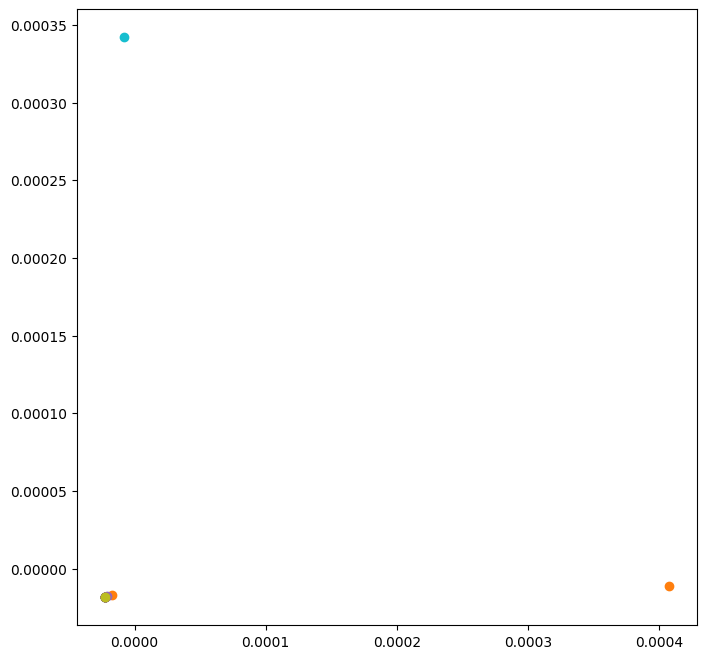

In [35]:
# Get the embeddings as a NumPy array
embeddings_numpy = embeddings.numpy()

# Perform PCA for dimensionality reduction to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_numpy)

# Plot the embeddings
plt.figure(figsize=(8, 8))
for i, label in enumerate(graph.nodes):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], label=label)

for i, label in enumerate(graph.nodes):
    plt.annotate(label, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

plt.title("Node Embeddings Visualization")
plt.legend()
plt.show()


In [36]:
import torch
import plotly.express as px
from sklearn.decomposition import PCA

# Get the embeddings as a NumPy array
embeddings_numpy = embeddings.numpy()

# Perform PCA for dimensionality reduction to 2D
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_numpy)

# Create a DataFrame for Plotly
import pandas as pd
df = pd.DataFrame(embeddings_2d, columns=['X', 'Y'])
df['Label'] = list(graph.nodes)

# Create an interactive scatter plot using Plotly Express
fig = px.scatter(df, x='X', y='Y', text='Label', title='Node Embeddings Visualization', labels={'text': 'Node'})
fig.update_traces(textposition='top center')

# Show the interactive plot
fig.show()

# WEMBEDDER

In [3]:
most_similar = requests.get('https://wembedder.toolforge.org/api/most-similar/Q245016')
most_similar.json()

{'model_metadata': {'filename': 'wikidata-20170613-truthy-BETA-cbow-size=100-window=1-min_count=20-iter=25'},
 'most_similar': [{'item': 'Q131093', 'similarity': 0.892484188079834},
  {'item': 'Q207505', 'similarity': 0.8920884132385254},
  {'item': 'Q1907114', 'similarity': 0.8913936614990234},
  {'item': 'Q17202187', 'similarity': 0.888986349105835},
  {'item': 'Q588140', 'similarity': 0.8888815641403198},
  {'item': 'Q2026833', 'similarity': 0.8846322298049927},
  {'item': 'Q81917', 'similarity': 0.8815812468528748},
  {'item': 'Q3455524', 'similarity': 0.8814383745193481},
  {'item': 'Q2072352', 'similarity': 0.8813960552215576},
  {'item': 'Q4976993', 'similarity': 0.8808416724205017}],
 'size_of_vocabulary': 609471}

In [4]:
kg_embedding1 = requests.get('https://wembedder.toolforge.org/api/vector/Q577975')
kg_embedding2 = requests.get('https://wembedder.toolforge.org/api/vector/Q145')
response1 = kg_embedding1.json()
response2 = kg_embedding2.json()

**Checking if computing the cosine similarity between two KGEs gives the same results as using the API**

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

In [6]:
vector1 = np.array(response1['vector'])
vector2 = np.array(response2['vector'])

In [7]:
vector1

array([-0.38532627,  0.5438596 ,  0.12567946,  0.09891756, -0.00967367,
        0.23936477,  0.04167237,  0.44911453, -0.1193116 ,  0.10101666,
        0.02472358, -0.08311547,  0.40223691,  0.1300448 , -0.1052963 ,
        0.03148704,  0.02385663, -0.47584987, -0.28337911, -0.09934869,
        0.05908589, -0.22871584, -0.37183791,  0.25666159,  0.2205507 ,
        0.45890251,  0.15781568, -0.07801353, -0.01235981, -0.07341474,
       -0.14785922, -0.54308766,  0.37210855, -0.2995742 , -0.02057274,
        0.31158045,  0.097432  , -0.08230967, -0.2845372 ,  0.19885573,
       -0.18794031,  0.12551367, -0.09506234, -0.18125331,  0.20180839,
        0.07243048,  0.19955644,  0.0966603 ,  0.124161  ,  0.02501899,
        0.21844281,  0.03153302,  0.22729002,  0.22689222,  0.07584095,
       -0.59838378,  0.08028194, -0.11139906, -0.31409833,  0.39930883,
       -0.20849864,  0.02170568, -0.25742292,  0.27044669,  0.05849862,
       -0.10320395, -0.29948372, -0.31399751,  0.00090432,  0.20

In [8]:
print(cosine_similarity(vector1.reshape(1, -1), vector2.reshape(1, -1)))

[[0.26326934]]


In [5]:
similarity = requests.get('https://wembedder.toolforge.org/api/similarity/Q18708370/Q245016')
similarity.json()

{'message': 'Not found: Q18708370', 'status': 404}

## Constructing the dataset

In [8]:
class KGEsWithWembedder:
    '''
    This class computes knowledge graph embeddings for entities in the TREx dataset
    using the Wembedder API based on the Wikidata knowledge graph and the RDF2Vec model.
    It saves the embeddings for the subject and object entities in a CSV file.
    '''
    def __init__(self, dataset: str):
        self.dataset = dataset
        self.api_url = "https://wembedder.toolforge.org/api/vector/"

    def compute_embedding(self, entity: str) -> list:
        api_url = f"{self.api_url}{entity}"
        response = requests.get(api_url)
        if response.status_code == 200:
            return response.json()['vector']
        else:
            return None
    
    def read_data(self) -> list:
        with open(self.dataset, 'r') as jsonl_file:
            lines = jsonl_file.readlines()
        
        return lines
    
    def extract_metadata(self, entry: dict) -> dict:
        return{
            'sub_label': entry['sub_label'],
            'sub_uri': entry['sub_uri'],
            'obj_label': entry['obj_label'],
            'obj_uri': entry['obj_uri'],
            'predicate_label': entry['predicate_label'],
            'predicate_id': entry['predicate_id'],
        }
    
    def process_data(self):
        lines = self.read_data()
        for line in tqdm(lines):
            entry = json.loads(line)
            metadata = self.extract_metadata(entry)
            sub_vector = self.compute_embedding(metadata['sub_uri'])
            obj_vector = self.compute_embedding(metadata['obj_uri'])
            metadata['sub_vector'] = sub_vector
            metadata['obj_vector'] = obj_vector
            yield metadata

    def save_to_csv(self, output_file_path: str):
        df = pd.DataFrame(self.process_data())
        df.to_csv(output_file_path, index=False, sep=';')
        print(f"Vectors saved to {output_file_path}")

# Example usage
dataset = "../data/dataset/TREx_all.jsonl"
output_file_path = "../data/dataset/wembedder/wembedder_vectors.csv"
kges = KGEsWithWembedder(dataset)
kges.save_to_csv(output_file_path)


  0%|          | 0/18249 [00:00<?, ?it/s]

 21%|██▏       | 3911/18249 [1:01:56<3:47:06,  1.05it/s]


ConnectTimeout: HTTPSConnectionPool(host='wembedder.toolforge.org', port=443): Max retries exceeded with url: /api/vector/Q5638 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x296e7d240>, 'Connection to wembedder.toolforge.org timed out. (connect timeout=None)'))

# PYKEEN

In [2]:
# load the dataset from the jsonl file
triples = []
with open('../data/dataset/TREx_all.jsonl', 'r') as jsonl_file:
    for line in jsonl_file:
        triple = json.loads(line)
        triples.append([triple['sub_label'], triple['predicate_label'], triple['obj_label']])

print(triples[:3])
# create a TriplesFactory instance
tf = TriplesFactory.from_labeled_triples(np.array(triples))
print(tf)

# split the dataset into train and validation sets (THIS CURRENTLY DOES NOT WORK, perhaps too few relations)
# training, validation = tf.split([0.8, 0.2]) #random_state=0)

# load pretrained FastText embeddings
fasttext_model = api.load('fasttext-wiki-news-subwords-300')

# initialize entity embeddings with FastText
entity_embedding_init = []
embedding_dim = 300
default_embedding = np.random.normal(size=(embedding_dim,))

for entity in tf.entity_id_to_label.values():
    try:
        embedding = fasttext_model.get_vector(entity)
    except KeyError:
        embedding = default_embedding
    entity_embedding_init.append(embedding)

entity_embedding_init = torch.tensor(entity_embedding_init)


[['Shreela Ghosh', 'occupation', 'actor'], ['Naomi Shihab Nye', 'occupation', 'poet'], ['Frits Helmuth', 'occupation', 'actor']]
TriplesFactory(num_entities=17220, num_relations=21, create_inverse_triples=False, num_triples=18239)


/var/folders/6g/j53lvv8s6q74m_39tzs1qcdc0000gn/T/ipykernel_2627/3279145782.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:264.)
  entity_embedding_init = torch.tensor(entity_embedding_init)


In [18]:
print(entity_embedding_init.shape)
print(entity_embedding_init[0])

torch.Size([17220, 300])
tensor([ 9.3077e-03, -2.2952e-03, -2.3018e-02, -2.8553e-02,  9.3823e-03,
         1.1162e-02,  8.1465e-03,  1.0696e-02, -1.3843e-02, -4.5577e-02,
         2.6105e-02,  2.2726e-02, -3.2947e-02,  1.5064e-02,  1.3498e-02,
         4.4300e-03, -8.5974e-03, -4.3659e-02, -3.0986e-02, -1.4014e-02,
        -3.9984e-03, -1.3948e-02,  7.0212e-02,  2.3214e-03,  7.3424e-03,
         2.7680e-02, -2.3920e-02, -4.3483e-02, -4.5026e-02, -3.6182e-02,
         9.7703e-03,  5.0388e-03,  1.2714e-02,  2.4161e-02, -4.6672e-03,
         2.1688e-04, -9.1624e-03,  1.4139e-02,  1.2857e-02, -2.3443e-02,
        -2.3531e-02,  2.2747e-02, -3.8743e-03, -3.6137e-02, -3.2369e-02,
        -3.8260e-02, -1.7464e-02,  4.2946e-02,  2.0026e-02, -2.2079e-03,
        -2.4003e-02, -5.4529e-02,  1.7860e-02,  2.6044e-03,  1.7041e-02,
        -1.0432e-03, -3.1273e-02,  2.3315e-02,  4.0822e-02,  3.0768e-02,
         3.2979e-02, -1.7217e-02, -8.7812e-03, -3.2567e-03, -4.7498e-02,
        -2.0594e-02, -4.75

In [16]:
# istantiate the TrasnE model with the initialized entity embeddings
model = TransE(
    triples_factory=tf,
    embedding_dim=300,
    # entity_initializer=torch.nn.init.constant_,
    # entity_init_kwargs=dict(val=entity_embedding_init),
    random_seed=42,
)
model.entity_representations[0].embeddings = entity_embedding_init

# train the model
training_loop = SLCWATrainingLoop(
    model=model,
    triples_factory=tf,
    optimizer=torch.optim.Adam(model.get_grad_params(), lr=0.001),
)
training_loop.train(triples_factory=tf, num_epochs=50, batch_size=256)

Training epochs on cpu: 100%|██████████| 50/50 [01:19<00:00,  1.58s/epoch, loss=0.011, prev_loss=0.0126]   


[0.9132475662562582,
 0.4005699468155702,
 0.2175310409317414,
 0.1326635211913122,
 0.09420478778580825,
 0.06882964064263636,
 0.04868976161297825,
 0.03925432993694105,
 0.03254082281556395,
 0.029388439789828327,
 0.025428994791582227,
 0.02365192926178376,
 0.01954182327285202,
 0.01932482286873791,
 0.016728743859049346,
 0.01639665114796824,
 0.016188112993000284,
 0.014537442734258043,
 0.013293360243551433,
 0.013630576793932252,
 0.013395716222779205,
 0.012343728772571517,
 0.011235276392350594,
 0.011616028069208065,
 0.010528178419917822,
 0.01303805844185667,
 0.010061086414174901,
 0.01150846762013518,
 0.010658202873956826,
 0.01247154658388657,
 0.012184604226301113,
 0.010485908126510266,
 0.012378222102092372,
 0.01093926873161561,
 0.011607787313146723,
 0.011469843435204692,
 0.01035717600542638,
 0.013130909970237149,
 0.012546284072515037,
 0.010586611823075347,
 0.0092589316643878,
 0.00924537343154144,
 0.011599424709048536,
 0.012048949707402952,
 0.0121747796

In [17]:
entity_embeddings = model.entity_representations[0].embeddings.detach().numpy()
print(entity_embeddings[0])

[ 9.30770021e-03 -2.29520001e-03 -2.30180006e-02 -2.85529997e-02
  9.38230008e-03  1.11619998e-02  8.14650021e-03  1.06960004e-02
 -1.38429999e-02 -4.55770008e-02  2.61049997e-02  2.27259994e-02
 -3.29470001e-02  1.50640002e-02  1.34979999e-02  4.43000020e-03
 -8.59740004e-03 -4.36590016e-02 -3.09859999e-02 -1.40140001e-02
 -3.99840018e-03 -1.39480000e-02  7.02119991e-02  2.32139998e-03
  7.34240003e-03  2.76800003e-02 -2.39199996e-02 -4.34830002e-02
 -4.50260006e-02 -3.61820012e-02  9.77030024e-03  5.03880018e-03
  1.27140004e-02  2.41609998e-02 -4.66720015e-03  2.16879998e-04
 -9.16239992e-03  1.41390003e-02  1.28570003e-02 -2.34430004e-02
 -2.35309992e-02  2.27470007e-02 -3.87430005e-03 -3.61369997e-02
 -3.23689990e-02 -3.82600017e-02 -1.74640007e-02  4.29459997e-02
  2.00260002e-02 -2.20789993e-03 -2.40030009e-02 -5.45290001e-02
  1.78599991e-02  2.60440004e-03  1.70409996e-02 -1.04320003e-03
 -3.12729999e-02  2.33149994e-02  4.08219993e-02  3.07679996e-02
  3.29790004e-02 -1.72169

In [9]:
relation_embeddings = model.relation_representations
print(relation_embeddings)

ModuleList(
  (0): Embedding(
    (_embeddings): Embedding(21, 300)
  )
)


In [36]:
# making it pretty

class DataLoader:
    def __init__(self, file_path: str):
        self.file_path = file_path
    
    def load_data(self):
        triples = []
        with open(self.file_path, 'r') as jsonl_file:
            for line in jsonl_file:
                triple = json.loads(line)
                triples.append([triple['sub_label'], triple['predicate_label'], triple['obj_label']])
        return triples
    

class WordEmbeddingLoader:
    def __init__(self, model_name) -> None:
        self.model_name = model_name

    def load_embedding_model(self):
        return api.load(self.model_name)


class EntityEmbeddingInitializer:
    def __init__(self, triples_factory: TriplesFactory, embedding_model, embedding_dim=300) -> None:
        self.triples_factory = triples_factory
        self.embedding_model = embedding_model
        self.embedding_dim = embedding_dim
    
    def initialize_entity_embeddings(self):
        entity_embedding_init = []
        default_embedding = np.random.normal(size=(self.embedding_dim,))

        for entity in tqdm(self.triples_factory.entity_id_to_label.values()):
            logging.info('Initializing entity embeddings')
            try:
                embedding = self.embedding_model.get_vector(entity)
            except KeyError:
                embedding = default_embedding
            entity_embedding_init.append(embedding)

        logging.info('Finished initializing entity embeddings')
        return torch.tensor(entity_embedding_init)


class KnowledgeGraphEmbeddingModel:
    def __init__(
            self, triples_factory: TriplesFactory,
            entity_embedding_init: torch.tensor,
            embedding_dim=300,
            random_seed=42) -> None:

        self.triples_factory = triples_factory
        self.entity_embedding_init = entity_embedding_init
        self.embedding_dim = embedding_dim
        self.random_seed = random_seed

    def initialize_model(self):
        model = TransE(
            triples_factory=self.triples_factory,
            embedding_dim=self.embedding_dim,
            random_seed=self.random_seed,
        )
        model.entity_representations[0].embeddings = self.entity_embedding_init
        return model


class TrainingLoop:
    def __init__(self, model, triples_factory: TriplesFactory, learning_rate=0.001, num_epochs=50, batch_size=256) -> None:
        self.model = model
        self.triples_factory = triples_factory
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.batch_size = batch_size
    
    def train_model(self):
        training_loop = SLCWATrainingLoop(
            model=self.model,
            triples_factory=self.triples_factory,
            optimizer=torch.optim.Adam(self.model.get_grad_params(), lr=self.learning_rate),
        )
        training_loop.train(triples_factory=self.triples_factory, num_epochs=self.num_epochs, batch_size=self.batch_size)


class EmbeddingSaver:
    def __init__(self, entities, embeddings, file_path):
        self.entities = entities
        self.embeddings = embeddings
        self.file_path = file_path

    def save_embeddings(self):
        with open(self.file_path, 'w', newline='') as embedding_file:
            writer = csv.writer(embedding_file)
            writer.writerow(["Entity", "Embedding"])
            
            for entity, embedding in zip(self.entities, self.embeddings):
                writer.writerow([entity] + [embedding.tolist()])

In [17]:
# Usage
data_loader = DataLoader('../data/dataset/TREx_all.jsonl')
triples_data = data_loader.load_data()

tf = TriplesFactory.from_labeled_triples(np.array(triples_data))

embedding_loader = WordEmbeddingLoader('fasttext-wiki-news-subwords-300')
fasttext_model = embedding_loader.load_embedding_model()

entity_embedding_initializer = EntityEmbeddingInitializer(tf, fasttext_model)
entity_embedding_init = entity_embedding_initializer.initialize_entity_embeddings()

INFO:gensim.models.keyedvectors:loading projection weights from /Users/giacomomunda/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz
INFO:gensim.utils:KeyedVectors lifecycle event {'msg': 'loaded (999999, 300) matrix of type float32 from /Users/giacomomunda/gensim-data/fasttext-wiki-news-subwords-300/fasttext-wiki-news-subwords-300.gz', 'binary': False, 'encoding': 'utf8', 'datetime': '2024-01-26T10:55:39.689674', 'gensim': '4.3.2', 'python': '3.10.1 (v3.10.1:2cd268a3a9, Dec  6 2021, 14:28:59) [Clang 13.0.0 (clang-1300.0.29.3)]', 'platform': 'macOS-14.0-arm64-arm-64bit', 'event': 'load_word2vec_format'}
  0%|          | 0/17220 [00:00<?, ?it/s]INFO:root:Initializing entity embedding for .af
INFO:root:Initializing entity embedding for 1-UP Studio
INFO:root:Initializing entity embedding for 100-year flood
INFO:root:Initializing entity embedding for 111 Eighth Avenue
INFO:root:Initializing entity embedding for 11th Panzer Division
INFO:root:Initializing entit

In [20]:
kg_model = KnowledgeGraphEmbeddingModel(tf, entity_embedding_init)
model_instance = kg_model.initialize_model()

training_loop = TrainingLoop(model_instance, tf)
training_loop.train_model()

Training epochs on cpu: 100%|██████████| 50/50 [01:17<00:00,  1.54s/epoch, loss=0.011, prev_loss=0.0126]   


In [37]:
# Save embeddings to a file
kg_embeddings = model_instance.entity_representations[0].embeddings.detach().numpy()
entities = [entity for entity in tf.entity_id_to_label.values()]

# Save embeddings to a CSV file
embedding_saver = EmbeddingSaver(entities, kg_embeddings, 'kg_embeddings.csv')
embedding_saver.save_embeddings()

In [24]:
entity_embeddings = model_instance.entity_representations[0].embeddings.detach().numpy()
print(entity_embeddings)

[[ 0.0093077  -0.0022952  -0.023018   ... -0.014939   -0.011355
  -0.0268    ]
 [ 1.29065623  0.71141165 -0.14889971 ... -1.11343313 -0.07937395
  -1.0496692 ]
 [ 1.29065623  0.71141165 -0.14889971 ... -1.11343313 -0.07937395
  -1.0496692 ]
 ...
 [ 1.29065623  0.71141165 -0.14889971 ... -1.11343313 -0.07937395
  -1.0496692 ]
 [ 1.29065623  0.71141165 -0.14889971 ... -1.11343313 -0.07937395
  -1.0496692 ]
 [ 1.29065623  0.71141165 -0.14889971 ... -1.11343313 -0.07937395
  -1.0496692 ]]


# pyRDF2Vec

https://github.com/IBCNServices/pyRDF2Vec